# Numerical Solutions of ODEs

When solving ordinary differential equations (ODEs) numerically, we observe a fundamental distinction between two primary types of approaches:

* **Explicit Methods**: The value at the next step ($y_{i+1}$) is calculated **directly** from values that are already known from the current step or previous steps. While these methods are highly intuitive and very easy to program, they suffer from severe **numerical stability constraints**. If the chosen step size $h$ is too large, the truncation errors propagate exponentially, causing the numerical solution to "explode" and diverge completely from the true solution.
* **Implicit Methods**: The value at the next step ($y_{i+1}$) appears on **both sides of the equation** (it is embedded within the future derivative term). This structural property grants these methods exceptional—often unconditional—numerical stability. Consequently, the solution will never explode, even when using exceptionally large step sizes ($h$). On the downside, they are significantly harder to solve. If the derivative function $f$ is non-linear, an auxiliary root-finding algorithm (such as Newton-Raphson) must be implemented at every single step to isolate $y_{i+1}$. This increases computational complexity and significantly complicates the underlying code.

### Runge-Kutta Method

The Runge-Kutta 4th order method is a **single-step** (one-step) method used to compute the value of a function at the next time step based solely on the current step's value, without requiring the history of previous steps. This independent step nature makes it highly efficient computationally compared to multi-step methods.

Within each step, the algorithm calculates four distinct slopes in a **sequential process**, where each slope evaluation builds upon the result of the preceding one:

* **$F_1$**: This is the exact slope of the ODE (the derivative) evaluated at our current starting point. It is identical to the slope used in the standard, explicit Euler's method.
* **$F_2$**: The first slope estimate at the **midpoint**. We take a half-step forward along the $x$-axis ($\frac{h}{2}$) and predict the corresponding $y$ value using the initial slope $F_1$. 
* **$F_3$**: An improved slope estimate at the midpoint. We evaluate the $y$ value at the same midpoint again, but this time we utilize the updated slope $F_2$ for a more accurate prediction.
* **$F_4$**: The slope estimate at the end of the interval ($x_i + h$). It is evaluated by taking a full step forward based on the refined midpoint slope $F_3$.

This sequential refinement is what grants the method its remarkable accuracy. In the final structural formula, the weights assigned to these slopes are $1, 2, 2, 1$, normalized by dividing by $6$ (the sum of the weights):

$$\text{Average Slope} = \frac{F_1 + 2F_2 + 2F_3 + F_4}{6}$$

This weighting formulation is not accidental—it matches the integration weights of **Simpson's Rule** perfectly. The midpoint slopes ($F_2$ and $F_3$) are given double weight because they better represent the overall trajectory of the curve across the interval.

Because RK4 is an **explicit method**, it is susceptible to numerical instability (error propagation/explosion) when solving **stiff problems** or when the chosen step size $h$ is too large. In such scenarios, the numerical solution can diverge rapidly from the true analytical solution, necessitating the use of **implicit methods**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def derivs(x, y):
    """
    Defines the Ordinary Differential Equation (ODE): dy/dx = f(x, y).
    Example: dy/dx = x * sqrt(y)
    """
    return x * np.sqrt(y)

def rk4_step(x, y, h, derivs_func):
    """
    Calculates a single step of the fourth-order Runge-Kutta method.
    """
_
    
    return ynew

def rk4_solver(x_start, x_end, y_init, h, derivs_func):
    """
    Integrates the ODE from x_start to x_end using the RK4 method.
    """
    # Calculate the number of steps required
    num_steps = int((x_end - x_start) / h)
    
    # Initialize arrays to store the trajectory
    x_pts = np.zeros(num_steps + 1)
    y_pts = np.zeros(num_steps + 1)
    
    # Set initial values
    x_pts[0] = x_start
    y_pts[0] = y_init
    
    # Time-stepping loop
    for i in range(num_steps):
        x_pts[i+1] = x_pts[i] + h
        y_pts[i+1] = rk4_step(x_pts[i], y_pts[i], h, derivs_func)
        
    return x_pts, y_pts

if __name__ == "__main__":
    # Define initial conditions and simulation parameters
    x_0 = 1.0       # Initial x
    y_0 = 1.0       # Initial y, matching y(1) = 1
    x_f = 2.0       # Final x boundary
    step_size = 0.1 # Step size (h)
    
    # Run the integrator
    x_sim, y_sim = rk4_solver(x_0, x_f, y_0, step_size, derivs)
    
    # Print the calculated value at the first step for verification
    print(f"Value at x = {x_sim[1]:.1f}: y = {y_sim[1]:.5f}")

Value at x = 1.1: y = 1.10776


### Predictor-Corrector

The **Predictor-Corrector** strategy is an algorithmic framework that combines the high numerical stability of **implicit methods** with the high computational efficiency of **explicit methods**.

* **The Predictor**: Computes a rough but rapid initial guess with an **explicit formula**. It utilizes an explicit method to obtain a temporary estimate for $y_{i+1}$. The most elementary example of a predictor is the explicit Euler's method.
* **The Corrector**: Refines the initial guess. Instead of algebraically isolating the future term in a complex, non-linear **implicit formula**, we simply substitute the predicted estimate ($y_{i+1}^*$) into the right-hand side of the implicit equation.

A major advantage of this framework is its iterative capability. The corrector phase can be applied repeatedly within the same time step. By continually feeding the newly corrected $y_{i+1}$ back into the implicit side, the solution rapidly converges toward a highly accurate value.

Today we will go over a very standard predictor-corrector method:

1. **Adams-Bashforth (AB4) as the Predictor**: An explicit formula that uses a linear combination of four past derivatives $(f_{i}, f_{i-1}, f_{i-2}, f_{i-3})$ to extrapolate the initial guess $y_{i+1}^*$.
2. **Adams-Moulton (AM4) as the Corrector**: An implicit formula that ingests the predicted state to enforce stability and tighten accuracy.

$$\begin{aligned}
\text{Predictor (AB4):} \quad & y_{i+1}^* = y_i + \frac{h}{24}\left(55f_i - 59f_{i-1} + 37f_{i-2} - 9f_{i-3}\right)  \\
\text{Corrector (AM4):} \quad & y_{i+1} = y_i + \frac{h}{24}\left(9f_{i+1}^* + 19f_i - 5f_{i-1} + f_{i-2}\right)
\end{aligned}$$

**The Catch**: Because this is a multi-step method, it cannot start natively from a single initial condition $(x_0, y_0)$ as it lacks the historical data points required by the formulas[. To bootstrap the algorithm, we must first compute the initial history (the first 3 steps) using a high-order single-step method, typically **Runge-Kutta 4th Order (RK4)**. Once four consecutive historical data nodes are established, the solver can transition fully to the explicit-implicit Adams loop.

Adams-Bashforth-Moulton 4th Order Trajectory Output:
Step  0 -> x = 1.00, y = 1.00000
Step  1 -> x = 1.10, y = 1.10776
Step  2 -> x = 1.20, y = 1.23210
Step  3 -> x = 1.30, y = 1.37476
Step  4 -> x = 1.40, y = 1.53760
Step  5 -> x = 1.50, y = 1.72266
Step  6 -> x = 1.60, y = 1.93210
Step  7 -> x = 1.70, y = 2.16826
Step  8 -> x = 1.80, y = 2.43360
Step  9 -> x = 1.90, y = 2.73076
Step 10 -> x = 2.00, y = 3.06250


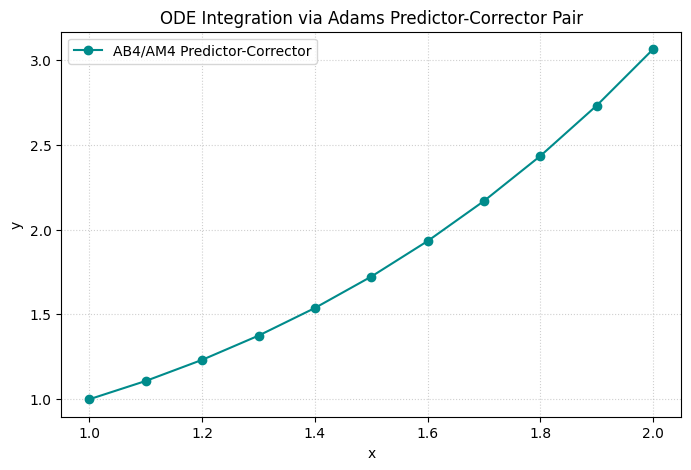

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def derivs(x, y):
    """
    Defines the ODE: dy/dx = f(x, y).
    Example from lecture notes: dy/dx = x * sqrt(y)
    """
    return x * np.sqrt(y)


def ab4_am4_solver(x_start, x_end, y_init, h, derivs_func, num_corrections=1):
    """
    Solves an IVP ODE using Adams-Bashforth 4th order as predictor
    and Adams-Moulton 4th order as corrector.
    """
    # 1. Calculate total number of steps
    num_steps = int((x_end - x_start) / h)
    
    # Initialize trajectory arrays - we add +1 to num_steps so we'll have a place to save the first value
    x_pts = np.zeros(num_steps + 1) 
    y_pts = np.zeros(num_steps + 1)
    f_pts = np.zeros(num_steps + 1)  # Array to store history of derivatives (f)
    
    # Set initial values
    x_pts[0] = x_start
    y_pts[0] = y_init
    f_pts[0] = derivs_func(x_pts[0], y_pts[0]) 
    
    # 2. Initialization Phase: Use RK4 for the first 3 steps (indices 1, 2, 3)
    # We need 4 historical points to kick off the Adams multi-step method.
    
    for i in range(3): # i=0 is for the 1st point we already know. i-1 is for the 2nd point. and so on....
_
    # now we have our 4 points and we can start the predictor-corrector!
    
    # 3. Main Multi-Step Loop (From index 3 to num_steps - 1)
    for i in range(3, num_steps):
        # Advance x boundary
        x_pts[i+1] = x_pts[i] + h
        
        # --- STEP A: Predictor (Adams-Bashforth 4th Order - Open Formula) ---
        # Uses explicit linear combination of 4 past derivatives: f_i, f_{i-1}, f_{i-2}, f_{i-3}
        y_pred = y_pts[i] + (h / 24.0) * (
            55.0 * f_pts[i] - 59.0 * f_pts[i-1] + 37.0 * f_pts[i-2] - 9.0 * f_pts[i-3]
        )
        
        # Evaluate initial guess of the derivative at the target point
        f_pred = derivs_func(x_pts[i+1], y_pred)
        
        # --- STEP B: Corrector Loop (Adams-Moulton 4th Order - Closed Formula) ---
        # Can be applied iteratively to refine the estimate of y_{i+1}
 # we don't want to override the original y_pred and f_pred!
_
#### NESTED LOOP: we need to use it to calculate different number of corrections than predictions ####
_
        
    return x_pts, y_pts


if __name__ == "__main__":
    # Define execution parameters matching lecture notes example (Page 8)
    x_0 = 1.0        # Starting point
    y_0 = 1.0        # Initial condition y(1) = 1
    x_f = 2.0        # Destination target point
    step_size = 0.1  # Step size (h)
    
    # Run solver with 1 corrector iteration per step
    x_sim, y_sim = ab4_am4_solver(x_0, x_f, y_0, step_size, derivs, num_corrections=1)
    
    # Display step-by-step output tracking array trajectories
    print("Adams-Bashforth-Moulton 4th Order Trajectory Output:")
    for idx in range(len(x_sim)):
        print(f"Step {idx:2d} -> x = {x_sim[idx]:.2f}, y = {y_sim[idx]:.5f}")
        
    # Optional: Visualizing the final integrated trajectory curve
    plt.figure(figsize=(8, 5))
    plt.plot(x_sim, y_sim, 'o-', color='darkcyan', label='AB4/AM4 Predictor-Corrector')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('ODE Integration via Adams Predictor-Corrector Pair')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()